# Mini Project - TravelPayouts Dataset 

## Objective
To analyze the global distribution and operational status of transportation facilities (airports, railways, bus stations, etc.), identify patterns in facility types and active vs. inactive infrastructure.
#### More specifically:
Which countries have the greatest airport infrastructure, and what proportion of that infrastructure is actively operational for flights?

## Overview
1. Load and explore the dataset
2. Data analysis: answer questions about the dataset
3. Conclusion

### Load Python Libraries

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

### Load and display the data

In [20]:
# Load dataset
url = "https://api.travelpayouts.com/data/en/airports.json"
response = requests.get(url)
airports = pd.DataFrame(response.json())

airports

,name_translations,city_code,country_code,time_zone,code,iata_type,name,coordinates,flightable
0,{'en': 'Bron'},LYS,FR,Europe/Paris,LYN,airport,Bron,"{'lat': 45.73083, 'lon': 4.943333}",False
1,{'en': 'Musgrave'},MVU,AU,Australia/Brisbane,MVU,airport,Musgrave,"{'lat': -14.166667, 'lon': 143.68333}",False
2,{'en': 'Yeovilton'},YEO,GB,Europe/London,YEO,airport,Yeovilton,"{'lat': 51.016666, 'lon': -2.55}",False
3,{'en': 'Refuge Cove SPB'},YRC,CA,America/Vancouver,YRC,airport,Refuge Cove SPB,"{'lat': 48.526764, 'lon': -71.05734}",False
4,{'en': 'Oskaloosa Municipal'},OOA,US,America/Chicago,OOA,airport,Oskaloosa Municipal,"{'lat': 41.3, 'lon': -92.65}",False
...,...,...,...,...,...,...,...,...,...
10349,{'en': 'Zaqatala'},ZTU,AZ,Asia/Baku,ZTU,airport,Zaqatala,"{'lat': 41.56166, 'lon': 46.664787}",False
10350,{'en': 'Space Coast Regional'},TIX,US,America/New_York,TIX,airport,Space Coast Regional,"{'lat': 28.512222, 'lon': -80.799446}",False
10351,{'en': 'Augusta Regional Airport'},AGS,US,America/New_York,AGS,airport,Augusta Regional Airport,"{'lat': 33.373665, 'lon': -81.973434}",True
10352,{'en': 'Mettle Field'},CEV,US,America/Indiana/Indianapolis,CEV,airport,Mettle Field,"{'lat': 39.65, 'lon': -85.13333}",False


### Explore Data (Exploratory Data Analysis)

In [3]:
airports.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10354 entries, 0 to 10353
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   name_translations  10354 non-null  object
 1   city_code          10354 non-null  object
 2   country_code       10354 non-null  object
 3   time_zone          10354 non-null  object
 4   code               10354 non-null  object
 5   iata_type          10354 non-null  object
 6   name               10354 non-null  object
 7   coordinates        10354 non-null  object
 8   flightable         10354 non-null  bool  
dtypes: bool(1), object(8)
memory usage: 657.4+ KB


In [4]:
airports.describe()

,name_translations,city_code,country_code,time_zone,code,iata_type,name,coordinates,flightable
count,10354,10354,10354,10354,10354,10354,10354,10354,10354
unique,10123,9470,241,397,10354,5,10123,10176,2
top,{'en': 'Heliport'},LON,US,America/Chicago,LYN,airport,Heliport,"{'lat': 51.51, 'lon': 0.06}",False
freq,32,16,2187,612,1,9254,32,8,6316


In [5]:
airports.shape

(10354, 9)

In [6]:
# Check for any null values
airports.isnull().sum()

name_translations    0
city_code            0
country_code         0
time_zone            0
code                 0
iata_type            0
name                 0
coordinates          0
flightable           0
dtype: int64

#### 1. What are the different types of facilities and how many of each? 

In [7]:
facility_counts = airports['iata_type'].value_counts()

print(facility_counts)

iata_type
airport     9254
railway      690
bus          184
heliport     174
harbour       52
Name: count, dtype: int64


#### 2. How many facilities are flightable (active for flights) vs. inactive?

In [39]:
#The .value_counts() method counts the occurrences of each unique value in the 'flightable' column
facility_status_counts = airports['flightable'].value_counts()

#Rename the index for a clearer output (True -> Flightable, False -> Inactive)
status_labels = {True: 'Flightable (Active for flights)', False: 'Inactive (Not operational)'}
fs_counts = facility_status_counts.rename(index=status_labels)

print(fs_counts)

flightable
Inactive (Not operational)         6316
Flightable (Active for flights)    4038
Name: count, dtype: int64


#### 3. What is the total number of countries with airports?

In [9]:
#Use the iata_type field to identify actual airports 
airports_only = airports[airports['iata_type'] == 'airport']

#Count airports by country
airport_counts = airports_only['country_code'].value_counts()

print(f"Total number of countries with airports: {len(airport_counts)}")

Total number of countries with airports: 240


#### 4. Which countries have the most airports?

In [10]:
country_counts = airports['country_code'].value_counts().head(10)

print("\n" + "="*36)
print("TOP 10 COUNTRIES WITH MOST AIRPORTS")
print("="*36)
print(country_counts)


TOP 10 COUNTRIES WITH MOST AIRPORTS
country_code
US    2187
CA     645
AU     625
PG     396
RU     351
BR     318
CN     282
ID     215
GB     192
DE     187
Name: count, dtype: int64


#### 5. Which countries have the highest number of active airports?

In [22]:
#Filter for ACTIVE AIRPORTS only (iata_type is "airport" AND flightable is True)
active_airports = airports[(airports['iata_type'] == 'airport') & (airports['flightable'] == True)]

#Count active airports by country
country_counts = active_airports['country_code'].value_counts()

#Display top 10 countries
top_10_countries = country_counts.head(10)

print("\n" + "="*43)
print("TOP 10 COUNTRIES WITH MOST ACTIVE AIRPORTS")
print("="*43)
print(top_10_countries)


TOP 10 COUNTRIES WITH MOST ACTIVE AIRPORTS
country_code
US    572
RU    245
CN    221
CA    180
BR    132
AU    130
IN    119
ID     91
JP     77
MX     59
Name: count, dtype: int64


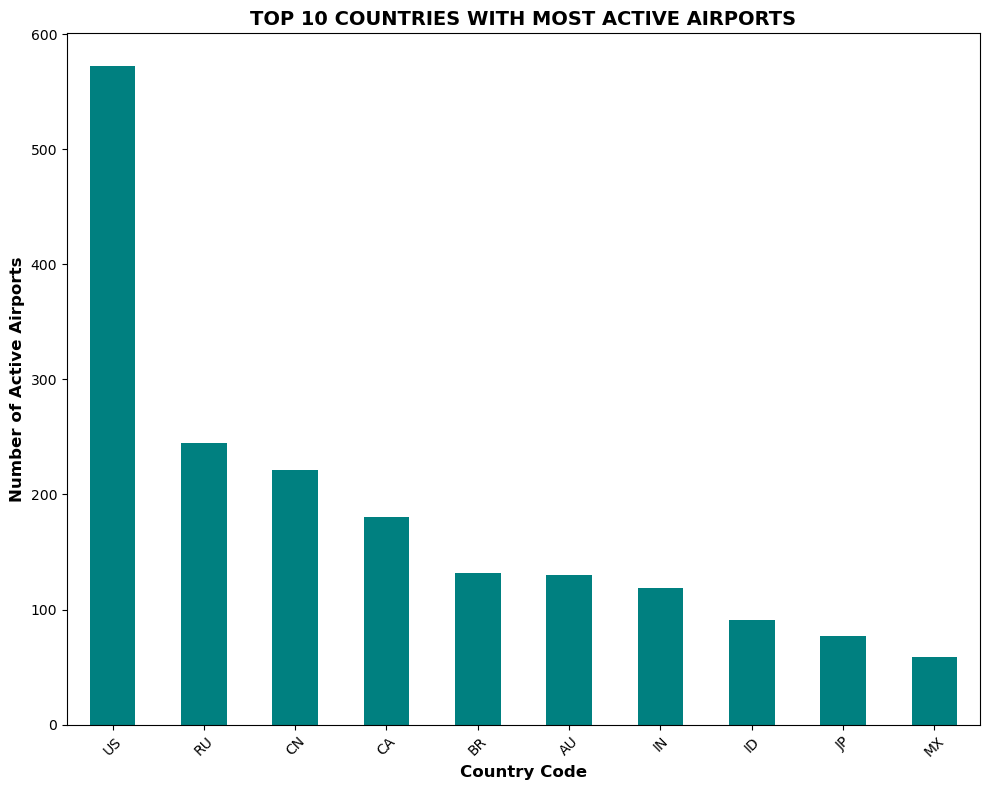

In [29]:
# Visualization: Bar Chart
plt.figure(figsize=(10, 8))
top_10_countries.plot(kind='bar', color='teal')
plt.title('TOP 10 COUNTRIES WITH MOST ACTIVE AIRPORTS', fontsize=14, fontweight='bold')
plt.xlabel('Country Code', fontsize=12, fontweight='bold')
plt.ylabel('Number of Active Airports', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 6.	Which countries have the most inactive airports?

In [13]:
inactive_by_country = airports_only[airports_only['flightable'] == False]['country_code'].value_counts()

print("\n" + "="*38)
print("TOP 10 COUNTRIES WITH MOST INACTIVE AIRPORTS")
print("="*38)
print(inactive_by_country.head(10))


TOP 10 COUNTRIES WITH MOST INACTIVE AIRPORTS
country_code
US    1488
AU     466
PG     373
CA     368
BR     186
ID     124
CO     114
FR      70
AR      66
DE      60
Name: count, dtype: int64


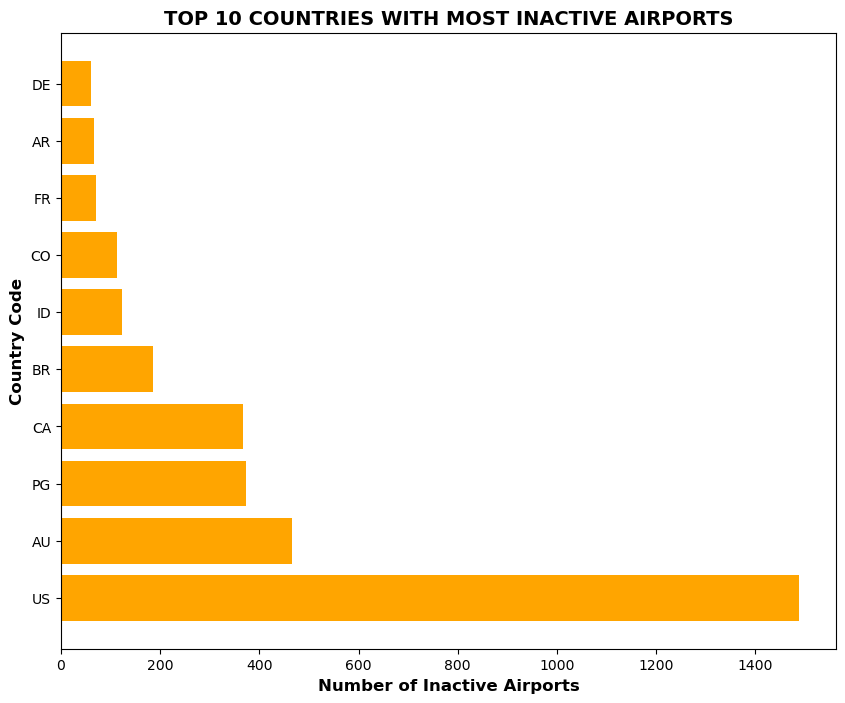

In [30]:
# Visualization: Horizontal Bar Chart
plt.figure(figsize=(10, 8))
top_inactive = inactive_by_country.head(10)
bars = plt.barh(range(len(top_inactive)), top_inactive.values, color='orange')
plt.title('TOP 10 COUNTRIES WITH MOST INACTIVE AIRPORTS', fontsize=14, fontweight='bold')
plt.ylabel('Country Code', fontsize=12, fontweight='bold')
plt.xlabel('Number of Inactive Airports', fontsize=12, fontweight='bold')
plt.yticks(range(len(top_inactive)), top_inactive.index)

plt.show()

#### 7.	Which countries have the highest percentage of active airports?

In [42]:
# Calculate activity rate by country
active_by_country = airports_only[airports_only['flightable'] == True]['country_code'].value_counts()
total_by_country = airports_only['country_code'].value_counts()
activity_rate = (active_by_country / total_by_country * 100)

print("\n" + "="*42)
print("TOP 10 COUNTRIES BY % OF ACTIVE AIRPORTS:")
print("="*42)
print(activity_rate.nlargest(50))


TOP 10 COUNTRIES BY % OF ACTIVE AIRPORTS:
country_code
AB    100.0
AI    100.0
AL    100.0
AM    100.0
AW    100.0
AX    100.0
BA    100.0
BB    100.0
BH    100.0
BN    100.0
BQ    100.0
BT    100.0
CC    100.0
CW    100.0
CX    100.0
DM    100.0
EH    100.0
FO    100.0
GE    100.0
GG    100.0
GI    100.0
GM    100.0
GQ    100.0
GU    100.0
HK    100.0
IM    100.0
JE    100.0
KG    100.0
KN    100.0
KY    100.0
LC    100.0
LU    100.0
MK    100.0
MO    100.0
MQ    100.0
MS    100.0
MT    100.0
MU    100.0
NF    100.0
NR    100.0
NU    100.0
PW    100.0
RE    100.0
SI    100.0
SJ    100.0
ST    100.0
SV    100.0
SX    100.0
TJ    100.0
TT    100.0
Name: count, dtype: float64


#### 8.	What percentage of airports are in the top 5 countries?

In [37]:
total_airports = len(airports_only)
top5_airports = airports_only['country_code'].value_counts().head(5).sum()
concentration_pct = (top5_airports / total_airports) * 100
print(f"Top 5 countries contain {concentration_pct:.1f}% of all airports")

Top 5 countries contain 42.3% of all airports


#### 9.	How many countries have only one airport?

In [17]:
single_airport_countries = airport_counts[airport_counts == 1].count()
print(f"{single_airport_countries} countries have exactly 1 airport")

36 countries have exactly 1 airport


#### 10. Which facility types are most likely to be active vs. inactive?

In [18]:
# Calculate percentage active by facility type
type_activity_rate = airports.groupby('iata_type')['flightable'].mean() * 100
print(type_activity_rate.sort_values(ascending=False))

iata_type
airport     39.572077
railway     38.695652
bus         38.586957
harbour     23.076923
heliport    14.942529
Name: flightable, dtype: float64


#### 11. Is there a correlation between total airports and activity rate?

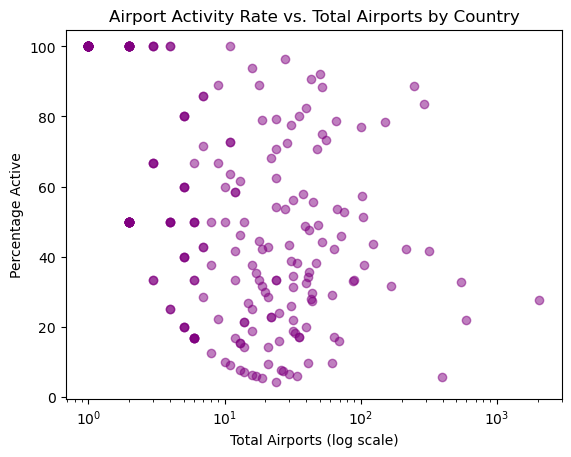

In [19]:
# Scatter plot: total airports vs. activity percentage
merged_data = pd.DataFrame({
    'Total': total_by_country,
    'Active_Pct': activity_rate
}).dropna()

plt.scatter(merged_data['Total'], merged_data['Active_Pct'], alpha=0.5, color='purple')
plt.xscale('log')
plt.xlabel('Total Airports (log scale)')
plt.ylabel('Percentage Active')
plt.title('Airport Activity Rate vs. Total Airports by Country')
plt.show()

## Conclusion:

Primary objectives: to identify countries with the greatest airport concentration and to assess the proportion of active vs. inactive airport infrastructure. 

In conclusion the United States has the greatest airport infrastructure with 2,187 total airports. However, nearly 3 out of 4 US airports in the database are inactive.


---



---



                                              by Aralis Santana


---



---
